In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

In [2]:
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])

In [3]:
import ast
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

In [4]:
df[['job_title_short','job_skills']].head(5)

,job_title_short,job_skills
0,Senior Data Engineer,None
1,Data Analyst,"[r, python, sql, nosql, power bi, tableau]"
2,Data Engineer,"[python, sql, c#, azure, airflow, dax, docker,..."
3,Data Engineer,"[python, c++, java, matlab, aws, tensorflow, k..."
4,Data Engineer,"[bash, python, oracle, aws, ansible, puppet, j..."


In [5]:
df_exploded=df.explode('job_skills')

In [6]:
skill_count=df_exploded.groupby(['job_title_short','job_skills']).size()


In [7]:
df_exploded.head(5)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,None,None
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,r,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,python,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,sql,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,nosql,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."


In [8]:
skill_count=skill_count.reset_index(name='job_count')

In [9]:
skill_count.sort_values('job_count',ascending=False)

,job_title_short,job_skills,job_count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
462,Data Analyst,chainer,1
432,Cloud Engineer,wrike,1
410,Cloud Engineer,theano,1
24,Business Analyst,chainer,1


In [10]:
job_title='Cloud Engineer' 
top_skills=10

dff=skill_count[skill_count['job_title_short']==job_title].head(top_skills)

In [11]:
dff

,job_title_short,job_skills,job_count
223,Cloud Engineer,airflow,260
224,Cloud Engineer,airtable,2
225,Cloud Engineer,alteryx,28
226,Cloud Engineer,angular,138
227,Cloud Engineer,angular.js,6
228,Cloud Engineer,ansible,812
229,Cloud Engineer,apl,2
230,Cloud Engineer,arch,3
231,Cloud Engineer,asana,3
232,Cloud Engineer,asp.net,19


In [12]:
dff=dff.sort_values('job_count')

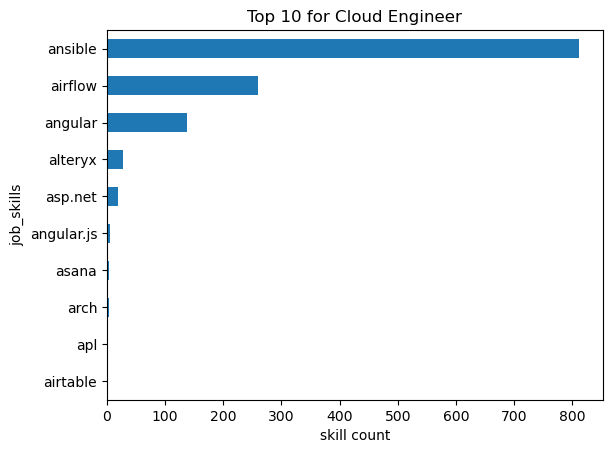

In [16]:
dff=dff.tail(10)
dff.plot(kind='barh',x='job_skills',y='job_count')
plt.gca().invert_yaxis
plt.title(f'Top {top_skills} for {job_title}')
plt.xlabel('skill count')
plt.legend().set_visible(False)
plt.show()